<a href="https://colab.research.google.com/github/franciscotovar/wtd/blob/main/Workshop4_From%20Signal%20to%20Metrics/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WEARABLE TECH DEVICES MIET2572**

IMPORTANT

Before starting:

Click File → Save a copy in Drive

Work ONLY on your copy

Do NOT edit the original notebook

# IMPORT YOUR DATA from the accelerometer sensor.
:
(Save as CSV first option PhyPhox)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

data = pd.read_csv(filename)

print(data.columns)  # for debugging
# Adapt automatically (simple version)
t  = data.iloc[:,0].values
ax = data.iloc[:,1].values
ay = data.iloc[:,2].values
az = data.iloc[:,3].values

acc_mag = np.sqrt(ax**2 + ay**2 + az**2)

fs = 1 / np.mean(np.diff(t))  # estimate sampling rate
t_full = t.copy()
acc_full = acc_mag.copy()

Saving Raw Data.csv to Raw Data.csv
Index(['Time (s)', 'Linear Acceleration x (m/s^2)',
       'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)',
       'Absolute acceleration (m/s^2)'],
      dtype='object')


---

# **Plot Raw Signal**

---



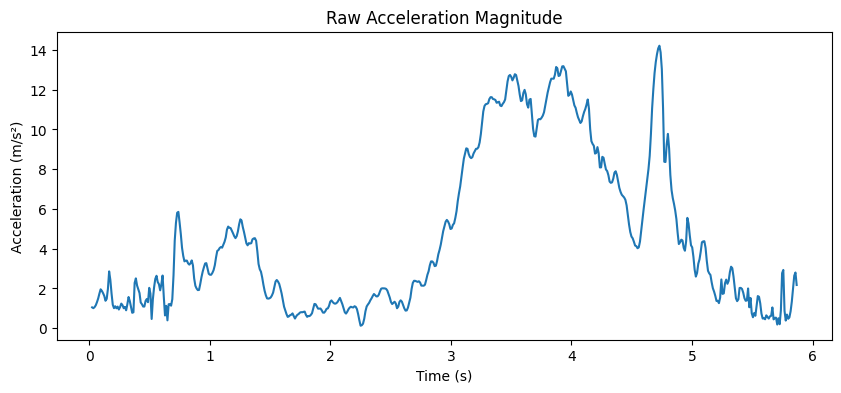

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(t, acc_mag, label="trial-1")

plt.title("Raw Acceleration Magnitude")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.show()

# **Region of Interest (ROI)**
Real wearable recordings often contain irrelevant regions
before or after the movement.
Selecting the analysis window is part of the signal model.

In [ ]:
start_time = 2
end_time = 4.3

roi = (t_full >= start_time) & (t_full <= end_time)

t = t_full[roi]
acc_mag = acc_full[roi]


# *Smoothing* (with Moving Average)*

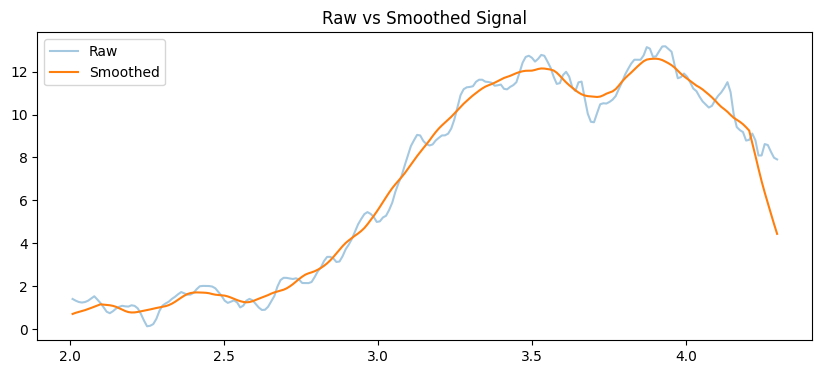

In [ ]:
window_size = int(0.2 * fs)  # 100 ms window
acc_smooth = np.convolve(acc_mag,
                         np.ones(window_size)/window_size,
                         mode='same')

plt.figure(figsize=(10,4))
plt.plot(t, acc_mag, alpha=0.4, label="Raw")
plt.plot(t, acc_smooth, label="Smoothed")
plt.legend()
plt.title("Raw vs Smoothed Signal")
plt.show()

# **Visualize events**

Detected Steps: 1
Threshold = 6.96 m/s^2
Minimum time between steps = 0.4 s


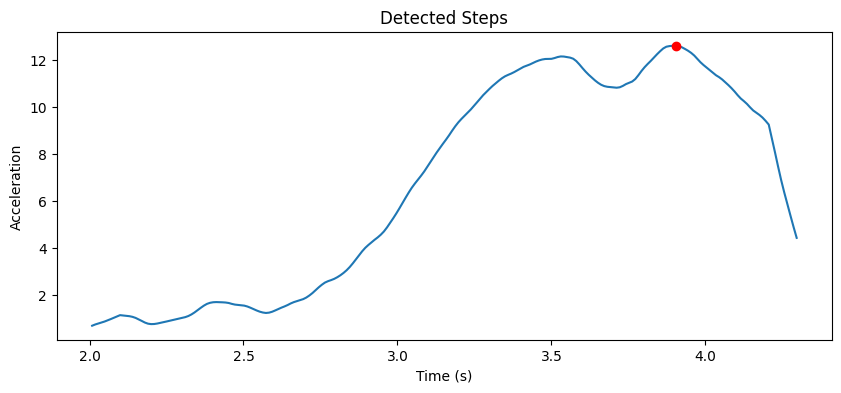

In [ ]:
# ===== MODEL PARAMETERS =====
alpha = 0.25            # amplitude offset above baseline
delta_t_min = 0.4      # minimum time between steps (seconds) # 400 ms physiological constraint

threshold = np.mean(acc_smooth) + alpha
min_distance = int(delta_t_min * fs)


peaks, _ = find_peaks(acc_smooth,
                      height=threshold,
                      distance=min_distance)

step_count = len(peaks)
print("Detected Steps:", step_count)
print(f"Threshold = {threshold:.2f} m/s^2")
print(f"Minimum time between steps = {delta_t_min} s")

plt.figure(figsize=(10,4))
plt.plot(t, acc_smooth)
plt.plot(t[peaks], acc_smooth[peaks], "ro")
plt.title("Detected Steps")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.show()

# **RMS  (Root Mean Square)**

•	measures the average magnitude of the signal

•	always positive

•	captures intensity, not events

•	signal with large peaks → high RMS

•	smooth signal → low RMS
# RMS summarizes overall signal intensity.


RMS: 8.09 m/s²


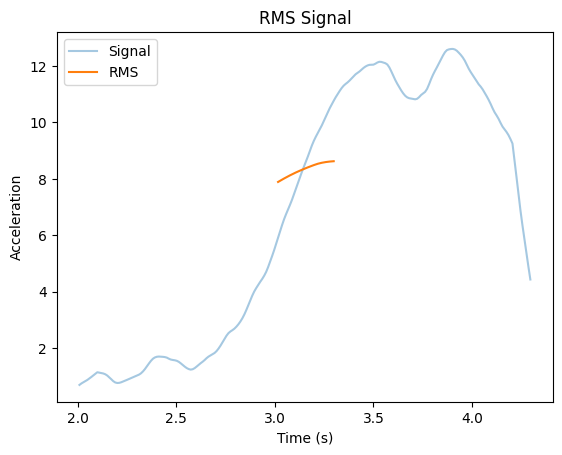

In [ ]:
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RMS global
rms = np.sqrt(np.mean(acc_smooth**2))
print(f"RMS: {rms:.2f} m/s²")

# RMS en ventana
window = 200  # samples
rms_signal = np.sqrt(pd.Series(acc_smooth**2).rolling(window, center=True).mean())

# Plot
plt.plot(t, acc_smooth, alpha=0.4, label='Signal')
plt.plot(t, rms_signal, label='RMS')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.title('RMS Signal')
plt.legend()
plt.show()


# **STD (variability)**


Measures variability and consistency in other words:
how spread out the signal is.

**A larger STD means the signal varies more over time.**

STD can be computed:
- within a single signal (variability over time or the data)
- across different signals (i.e. trials) (consistency of the intention or metric.)

For across trials:
- compute a metric per trial (e.g. RMS or peak)
- store values in a *list*
- compute STD of that *list*

# **Calculation within a signal**




In [ ]:
std_signal = np.std(acc_smooth)
print(f"Signal STD: {std_signal:.2f} m/s²")

Signal STD: 4.51 m/s²


# **Calculation within across trials**


list_trials_std = [std_signal-1, rstd_signal-2, std_signal-n...]

std_trials = np.std(list_trials_std)

print(std_trials)

In [ ]:
import numpy as np

std_trials = [1, 1, 1]

std_trials = np.std(std_trials)

print(f'Variability across trials: {std_trials:.2f} m/s²')

Variability across trials: 0.00 m/s²


# **Jerk: abruptness of motion**

Jerk changes continuously over time.
We can use RMS jerk to estimate the overall abruptness of the movement.

In [ ]:
dt = np.mean(np.diff(t))

jerk = np.gradient(acc_smooth, dt)
jerk = jerk[1:-10]# Remove edge artifacts from numerical differentiation

t_jerk = t[1:-10] # Remove edge artifacts from numerical differentiation


In [ ]:
jerk_rms = np.sqrt(np.mean(jerk**2))

print(f"Jerk RMS: {jerk_rms:.2f} m/s³")

Jerk RMS: 10.56 m/s³


Plot

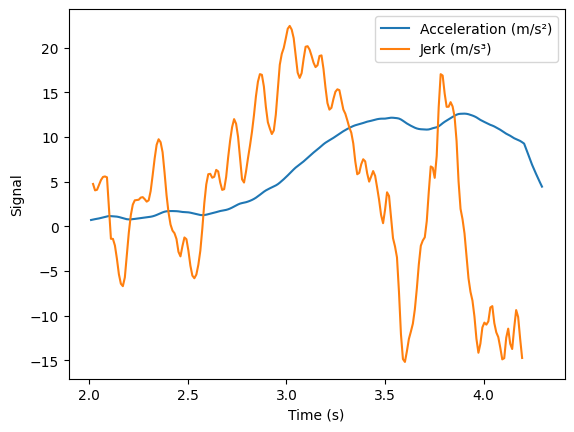

In [ ]:
plt.plot(t, acc_smooth, label='Acceleration (m/s²)')
plt.plot(t_jerk, jerk, label='Jerk (m/s³)')

plt.xlabel('Time (s)')
plt.ylabel('Signal')

plt.legend()

# **Cadence: rhythm over time**


* walking cadence 🚶
* tapping cadence
* pedalling cadence 🚲
* breathing cadence
* heart rate 💗
* etc.



In [ ]:
peak_times = t[peaks]

intervals = np.diff(peak_times)

if len(intervals) > 0:
    cadence = 60 / np.mean(intervals)
    print(f"Movement cadence: {cadence:.2f} events/min")
else:
    print("Not enough peaks detected to compute cadence.")

NameError: name 't' is not defined

# Reflection

- Which metric could support your project?
- Which metric best captured your *claim*?
- Which metric was most sensitive to noise?
- Could two wearable designers define the same *claim* differently?